<a href="https://colab.research.google.com/github/TanVi3001/MNIST_MLP_NoLibrary/blob/main/MNISTktv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Mượn thư viện trung lập ***scikit-learn*** và dùng hàm  **(fetch_openml)** --> Kéo dữ liệu ảnh về

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

print("Đang tải dữ liệu MNIST...")
# Tải dữ liệu MNIST (ảnh đã được trải phẳng sẵn thành 784 pixel)
mnist = fetch_openml('mnist_784', version=1, cache=True, parser='auto')

# Ép kiểu dữ liệu về mảng numpy
X = mnist.data.to_numpy() # X.shape sẽ có 70000 hàng - là tổng số hình ảnh(từ 0->9) và 784 cột - là tổng số lượng của mỗi hình ảnh sau khi duỗi thẳng
y = mnist.target.to_numpy().astype(int)

print(f"Kích thước X: {X.shape}")
print(f"Kích thước y: {y.shape}")

Đang tải dữ liệu MNIST...
Kích thước X: (70000, 784)
Kích thước y: (70000,)


## Chuẩn hóa và cắt dữ liệu thành 2 phần là
- Tập train: 60000 ảnh

- Tập test: 10000 ảnh


In [ ]:
# Chuẩn hóa dữ liệu về khoảng [0, 1]
X_normalized = X.astype('float32') / 255.0

# Chia tập Train (60.000 ảnh) và Test (10.000 ảnh)
X_train, X_test, y_train, y_test = train_test_split(X_normalized, y, test_size=10000, random_state=42)

print(f"Số lượng ảnh huấn luyện: {X_train.shape[0]}")
print(f"Số lượng ảnh kiểm tra: {X_test.shape[0]}")

Số lượng ảnh huấn luyện: 60000
Số lượng ảnh kiểm tra: 10000


## Để kết nối lớp đầu vào (784) và lớp đầu ra (10), ta cần thiết kế một Lớp ẩn (Hidden Layer) ở giữa để làm nhiệm vụ trích xuất các đặc trưng (như nhận diện nét thẳng, nét cong). Và lớp ẩn sẽ có 128 nơ - ron để suy nghĩ

--> Vậy kiến trúc tổng thể "bộ não" của ta sẽ là: 784 (Input) $\rightarrow$ 128 (Hidden) $\rightarrow$ 10 (Output).

## Để kết nối các lớp này, ta cần tạo ra các ma trận trọng số (Weight - W) và Độ lệch (Biases - b). Khi tín hiệu từ lớp đầu vào --> lớp ẩn thì phép toán mà mạng nơ-ron thực hiện nhân ma trận:

$$Z_1 = X \cdot W_1 + b_1$$

- Phép toán trong mạng nơ-ron $$Z_1 = X \cdot W_1$$

- X là ma trận đầu vào có kích thước là: 1x784 (1 hàng, 784 cột).

- Z1 là ma trận đầu ra có kích thước là: 1x128 (1 hàng, 128 cột).

--> Khi đó W sẽ có dạng W(784 hàng,128 cột)

### Và để hoàn thành lớp đầu ra thì ta cũng cần 1 ma trận độ lệch bias(b1). Vì mỗi nơ-ron trong số 128 nơ-ron của lớp ẩn cần 1 giá trị độ lệch riêng nên b1 sẽ có kích thước là 1x128.

## Từ lớp ẩn (128 nơ-ron) sang lớp đầu ra (10 nơ-ron) để đưa ra dự đoán cuối cùng

## Đầu ra của lớp ẩn (sau khi đi qua hàm kích hoạt) sẽ là một ma trận hàng kích thước $1 \times 128$. Phép tính tiếp theo là:$$Z_2 = A_1 \cdot W_2 + b_2$$

- Phép toán trong mạng nơ-ron
$$Z_2 = A_1 \cdot W_2$$

- A1 là ma trận có kích thước là 1x128

- Z2 là ma trận có kích thước là 1x10

--> W2 sẽ có dạng W2(128 hàng, 10 cột)

## Và kích thước bias(b2) của lớp này cũng chính là 1x10

In [ ]:
def init_params():
    # Khởi tạo ngẫu nhiên với giá trị nhỏ (nhân với 0.1) để dễ hội tụ
    W1 = np.random.randn(784, 128) * 0.1
    b1 = np.zeros((1, 128)) # [0,0,0,..,0]

    W2 = np.random.randn(128, 10) * 0.1
    b2 = np.zeros((1, 10))

    return W1, b1, W2, b2

W1, b1, W2, b2 = init_params()
print("Đã khởi tạo xong các ma trận Trọng số và Độ lệch!")

Đã khởi tạo xong các ma trận Trọng số và Độ lệch!


## Lan truyền tiến(Forward Propagation)

- Từ input -> hidden sài hàm ReLU để đảm bảo **tính phi tuyến**, tránh tiêu tốn dữ liệu **(Tính thưa thớt)**.

- Từ hidden -> Output sài hàm Softmax đề đưa về xác suất.

- ReLU

$$ f(x) = \max(0, x) $$


- Sofmax:
\begin{aligned}
\text{Softmax}(\mathbf{z})_i
&= \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad (\text{với } i = 1, 2, \dots, K) \\
&= \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
= \frac{e^{z_i - C}}{\sum_{j=1}^{K} e^{z_j - C}}
\end{aligned}

  + Giải pháp ổn định toán học **(Numerical Stability)**: Một tính chất của hàm Softmax là nếu ta trừ tất cả các phần tử đầu vào cho cùng một hằng số \(C\), kết quả Softmax không thay đổi --> Điều này giúp tránh cho giá trị của e^x với số quá lớn

  + Ví dụ:
  


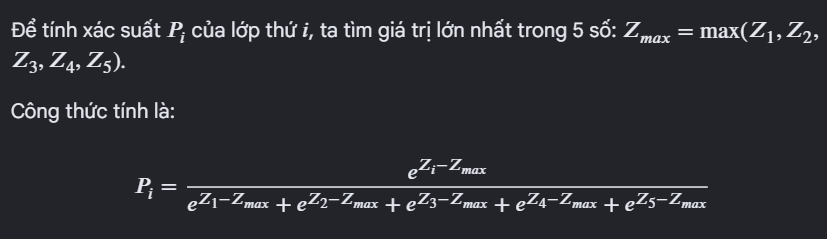

In [ ]:
def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    # Trừ đi giá trị max của mỗi hàng để tránh lỗi tràn bộ nhớ (overflow) khi tính e^x với số quá lớn
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True)) # keepdims = True: giữ nguyên số chiều của ma trận, axis = 1: Tính toán theo từng hàng
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = X.dot(W1) + b1
    A1 = ReLU(Z1)

    Z2 = A1.dot(W2) + b2
    A2 = softmax(Z2) # A2 chính là ma trận chứa xác suất dự đoán

    return Z1, A1, Z2, A2

# Cho cỗ máy "đoán mò" thử 5 bức ảnh đầu tiên trong tập Train
_, _, _, predictions = forward_prop(W1, b1, W2, b2, X_train[:5])

print("Xác suất dự đoán cho bức ảnh đầu tiên (10 nơ-ron):")
print(np.round(predictions[0], 3))
print(f"Tổng xác suất: {np.sum(predictions[0]):.0f}")

Xác suất dự đoán cho bức ảnh đầu tiên (10 nơ-ron):
[0.182 0.008 0.079 0.26  0.032 0.043 0.27  0.013 0.074 0.039]
Tổng xác suất: 1


## Lan truyền tiến sẽ random cái trọng số và lúc đầu random có thể khiến cho model học chưa tốt. Vì vậy ta cần phải lan truyền ngược để cập nhật lại ma trận trọng số cũng như là giá trị bias

- Tuy nhiên để mô hình tự sửa sai, trước tiên nó phải biết nó đang sai ở mức độ nào. Tức là chúng ta sẽ so sánh Xác suất dự đoán (A2) với đáp án thật (y) hay nói cách khác là so sánh cái giá trị dự đoán và đáp án thật.

- Sử dụng kỹ thuật mã hóa One-hot encoding để biểu diễn giá trị mình dự đoán là 1. Và sử dụng hàm mất mát Cross-Entropy và hàm kích hoạt Softmax tạo ra phép toán trong DL.

- Đạo hàm (sai số) tại lớp đầu ra $dZ_2$ được triệt tiêu các thành phần phức tạp và thu gọn lại chỉ còn là: Xác suất dự đoán trừ đi Xác suất thực tế ($A_2 - Y_{one\_hot}$).

   + Nếu hiệu này là nhỏ nhất thì học máy là học tốt
   + Nếu hiệu này là lớn thì học máy học



## Các công thức cần lưu ý:
### **Thuật toán Lan truyền ngược (Backward Propagation)**

Dưới đây là các công thức toán học được sử dụng trong hàm `backward_prop` để tính toán gradient phục vụ cho thuật toán Gradient Descent.

---

#### **1. Các ký hiệu sử dụng**
* $m$: Số lượng mẫu (bức ảnh) trong một batch ($m = \text{Y.size}$).
* $X$: Ma trận dữ liệu đầu vào.
* $Y$: Ma trận nhãn thực tế dưới dạng mã hóa One-hot ($Y = \text{one_hot_Y}$).
* $A_1, A_2$: Đầu ra của lớp ẩn và lớp dự đoán sau khi qua hàm kích hoạt.
* $Z_1, Z_2$: Giá trị tuyến tính đầu vào của hàm kích hoạt ở lớp ẩn và lớp đầu ra.
* $W_1, W_2$: Ma trận trọng số (weights) của lớp ẩn và lớp đầu ra.
* $b_1, b_2$: Vector chệch (bias) của lớp ẩn và lớp đầu ra.
* $\odot$: Phép nhân từng phần tử tương ứng (Element-wise multiplication).

---

#### **2. Công thức tính toán cho Lớp đầu ra (Lớp 2)**

* **Sai số tại lớp đầu ra ($dZ_2$):**
$$dZ_2 = A_2 - Y$$

* **Đạo hàm theo trọng số lớp 2 ($dW_2$):**
$$dW_2 = \frac{1}{m} A_1^T \cdot dZ_2$$

* **Đạo hàm theo bias lớp 2 ($db_2$):**
$$db_2 = \frac{1}{m} \sum_{\text{hàng}} dZ_2$$

---

#### **3. Công thức tính toán cho Lớp ẩn (Lớp 1)**

* **Sai số tại lớp ẩn ($dZ_1$):**
$$dZ_1 = (dZ_2 \cdot W_2^T) \odot g'(Z_1)$$

Trong đó, $g'(Z_1)$ là đạo hàm của hàm kích hoạt ReLU, được xác định theo điều kiện:
$$g'(Z_1) = \begin{cases} 1 & \text{nếu } Z_1 > 0 \\ 0 & \text{nếu } Z_1 \le 0 \end{cases}$$

* **Đạo hàm theo trọng số lớp 1 ($dW_1$):**
$$dW_1 = \frac{1}{m} X^T \cdot dZ_1$$

* **Đạo hàm theo bias lớp 1 ($db_1$):**
$$db_1 = \frac{1}{m} \sum_{\text{hàng}} dZ_1$$


In [ ]:
# Lan truyền ngược (Backward Propagation)
def one_hot(Y):
    # Tạo ma trận toàn số 0 với số hàng = số lượng ảnh, số cột = 10
    one_hot_Y = np.zeros((Y.size, 10)) # [0,0,0,0,0,0,0,0,0,0]
    # Điền số 1 vào đúng vị trí tương ứng với nhãn
    one_hot_Y[np.arange(Y.size), Y] = 1
    return one_hot_Y

def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = Y.size # Số lượng bức ảnh trong batch
    one_hot_Y = one_hot(Y)

    # 1. Tính sai số ở lớp đầu ra
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * A1.T.dot(dZ2)
    db2 = 1 / m * np.sum(dZ2, axis=0, keepdims=True)

    # 2. Truyền sai số ngược về lớp ẩn
    # Đạo hàm của ReLU: Nếu Z1 > 0 thì đạo hàm là 1, ngược lại là 0
    dZ1 = dZ2.dot(W2.T) * (Z1 > 0)
    dW1 = 1 / m * X.T.dot(dZ1)
    db1 = 1 / m * np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

## Việc chia cho m giúp cho NN tính 1 giá trị đạo hàm vừa đủ để tìm ra sai số trung bình phù hợp nhất

## Tiếp theo chính là việc model sẽ nhìn ảnh (Forward) -> Xem hình sai bao nhiêu (Backward) -> Sửa. Và ta cũng thêm 1 hàm tính độ chính xác (Accuracy) để theo dõi xem AI sẽ học ntn.

In [ ]:
# Là đạo hàm của hàm kích hoạt ReLU
def ReLU_deriv(Z):
    return Z > 0

# 1. Khởi tạo tham số ban đầu
'''def init_params():
    # Giả định: Đầu vào 784 pixel (28x28), Lớp ẩn 10 nút, Đầu ra 10 nút
    # Khởi tạo theo phương pháp He (cho ReLU) và Xavier để tránh vanishing gradient
    W1 = np.random.randn(784, 10) * np.sqrt(2. / 784)
    b1 = np.zeros((1, 10))
    W2 = np.random.randn(10, 10) * np.sqrt(2. / 10)
    b2 = np.zeros((1, 10))
    return W1, b1, W2, b2 '''

# 2. Cập nhật trọng số
def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

# 3. Đánh giá kết quả
def get_predictions(A2):
    return np.argmax(A2, axis=1)

def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size


In [ ]:
# Chia nhỏ dữ liệu thành các phần bằng nhau Mini-batch Gradient Descent -> Là cách chia tập dữ liệu lớn thành nhiều nhóm nhỏ (gọi là Batch size, thường chọn các kích thước là lũy thừa của 2 như 32, 64, 128, 256, 512)
# Mô hình sẽ lấy từng nhóm nhỏ (ví dụ 64 ảnh) ra để tính toán và cập nhật trọng số ngay lập tức. Sau khi duyệt qua hết tất cả các nhóm nhỏ đó thì mới tính là hoàn thành 1 Epoch (1 chu kỳ dữ liệu)

def get_batches(X, Y, batch_size):
    m = X.shape[0] # Tổng số lượng ảnh (60.000)

    # 1. Trộn ngẫu nhiên dữ liệu (Shuffle)
    # Lấy ra một mảng các chỉ số từ 0 đến 59.999 đã được xáo trộn
    permutation = np.random.permutation(m)
    X_shuffled = X[permutation, :]
    Y_shuffled = Y[permutation]

    # 2. Cắt thành các batch nhỏ
    batches = []
    for i in range(0, m, batch_size):
        X_batch = X_shuffled[i : i + batch_size, :]
        Y_batch = Y_shuffled[i : i + batch_size]
        batches.append((X_batch, Y_batch))

    return batches

def mini_batch_gradient_descent(X, Y, batch_size, alpha, epochs):
    W1, b1, W2, b2 = init_params()

    # Số lượng batch trong 1 epoch (60000 / 64 = 937 batches)
    num_batches = np.ceil(X.shape[0] / batch_size)

    for epoch in range(epochs):
        # Lấy danh sách các mini-batch (dữ liệu được xáo trộn mới mỗi epoch)
        batches = get_batches(X, Y, batch_size)

        for X_batch, Y_batch in batches:
            # 1. Lan truyền tiến (Chỉ tính trên 64 ảnh)
            Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X_batch)

            # 2. Lan truyền ngược (Chỉ tính sai số của 64 ảnh)
            dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X_batch, Y_batch)

            # 3. Cập nhật Trọng số ngay lập tức!
            W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)

        # In kết quả sau mỗi Epoch
        # (Để in độ chính xác, chúng ta phải quét lại toàn bộ tập X_train)
        _, _, _, A2_train = forward_prop(W1, b1, W2, b2, X)
        predictions = get_predictions(A2_train)
        acc = get_accuracy(predictions, Y)

        print(f"Epoch {epoch + 1:2d}/{epochs} | Trải qua {int(num_batches)} lần cập nhật | Độ chính xác: {acc * 100:.2f}%")

    return W1, b1, W2, b2

# --- BẮT ĐẦU HUẤN LUYỆN BẰNG MINI-BATCH ---
print("Khởi động Mini-batch Gradient Descent...")
# Vì học rất nhanh, ta chỉ cần 20 epochs (chạy lướt qua toàn bộ dữ liệu 20 lần)
W1_final, b1_final, W2_final, b2_final = mini_batch_gradient_descent(
    X_train, y_train, batch_size=64, alpha=0.1, epochs=20
)
print("Huấn luyện siêu tốc hoàn tất!")

# --- KIỂM TRA TRÊN TẬP TEST (ĐỀ THI CUỐI KỲ) ---
_, _, _, A2_test = forward_prop(W1_final, b1_final, W2_final, b2_final, X_test)
test_predictions = get_predictions(A2_test)
test_acc = get_accuracy(test_predictions, y_test)
print(f"ĐỘ CHÍNH XÁC TRÊN TẬP TEST (10.000 ẢNH): {test_acc * 100:.2f}%")

Khởi động Mini-batch Gradient Descent...
Epoch  1/20 | Trải qua 938 lần cập nhật | Độ chính xác: 93.08%
Epoch  2/20 | Trải qua 938 lần cập nhật | Độ chính xác: 95.28%
Epoch  3/20 | Trải qua 938 lần cập nhật | Độ chính xác: 96.21%
Epoch  4/20 | Trải qua 938 lần cập nhật | Độ chính xác: 96.94%
Epoch  5/20 | Trải qua 938 lần cập nhật | Độ chính xác: 97.16%
Epoch  6/20 | Trải qua 938 lần cập nhật | Độ chính xác: 97.76%
Epoch  7/20 | Trải qua 938 lần cập nhật | Độ chính xác: 97.97%
Epoch  8/20 | Trải qua 938 lần cập nhật | Độ chính xác: 98.25%
Epoch  9/20 | Trải qua 938 lần cập nhật | Độ chính xác: 98.47%
Epoch 10/20 | Trải qua 938 lần cập nhật | Độ chính xác: 98.63%
Epoch 11/20 | Trải qua 938 lần cập nhật | Độ chính xác: 98.76%
Epoch 12/20 | Trải qua 938 lần cập nhật | Độ chính xác: 98.74%
Epoch 13/20 | Trải qua 938 lần cập nhật | Độ chính xác: 99.00%
Epoch 14/20 | Trải qua 938 lần cập nhật | Độ chính xác: 99.12%
Epoch 15/20 | Trải qua 938 lần cập nhật | Độ chính xác: 99.15%
Epoch 16/20 | 

### **Lưu trữ "bộ não" (Model Saving) 💾**:Bằng cách này Ta sẽ nhận diện ảnh mà không cần phải bắt máy tính học lại từ đầu. Ta có thể dùng các hàm của NumPy để đóng gói và xuất các ma trận trọng số này ra thành một file trên ổ cứng.

In [ ]:
# --- 1. LƯU TRỮ MÔ HÌNH ---
# Dùng file npz để chứa nhiều mảng numpy cùng lúc
model_filename = 'numpy_mnist_model.npz'
np.savez(model_filename, W1=W1_final, b1=b1_final, W2=W2_final, b2=b2_final)
print(f"Đã lưu thành công bộ não vào file: {model_filename}")

# --- 2. TẢI LẠI MÔ HÌNH (Dùng cho lần sau không cần train lại) ---
loaded_data = np.load(model_filename)

# Trích xuất lại các ma trận bằng đúng cái tên lúc nãy mình lưu
W1_loaded = loaded_data['W1']
b1_loaded = loaded_data['b1']
W2_loaded = loaded_data['W2']
b2_loaded = loaded_data['b2']

print("Đã khôi phục thành công các ma trận trọng số!")

Đã lưu thành công bộ não vào file: numpy_mnist_model.npz
Đã khôi phục thành công các ma trận trọng số!


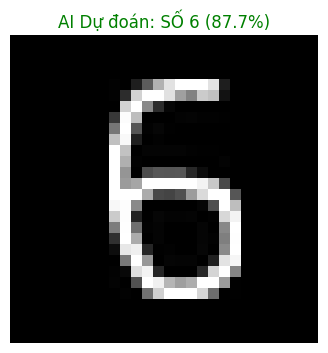

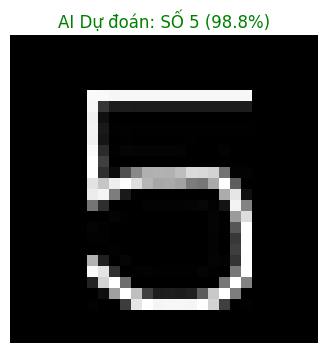

In [ ]:
import cv2
import numpy as np
from PIL import Image
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt

# ==========================================
# PHẦN 1: TẢI MÔ HÌNH VÀ TOÁN HỌC
# ==========================================
def load_model(filename='numpy_mnist_model.npz'):
    try:
        data = np.load(filename)
        return data['W1'], data['b1'], data['W2'], data['b2']
    except Exception as e:
        print("Lỗi: Không tìm thấy file model 'numpy_mnist_model.npz'.")
        return None, None, None, None

def ReLU(Z):
    return np.maximum(0, Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def forward_predict(X, W1, b1, W2, b2):
    Z1 = X.dot(W1) + b1
    A1 = ReLU(Z1)
    Z2 = A1.dot(W2) + b2
    A2 = softmax(Z2)
    return A2

# ==========================================
# PHẦN 2: "CON MẮT" TIỀN XỬ LÝ (CHUẨN MNIST)
# ==========================================
def preprocess_for_mnist(image_path, show_steps=False):
    # 1. Đọc ảnh và Khử nhiễu bằng Adaptive Threshold
    img_cv = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img_cv is None:
        print(f"Không tìm thấy ảnh: {image_path}")
        return None, None

    blurred = cv2.GaussianBlur(img_cv, (5, 5), 0)
    thresh = cv2.adaptiveThreshold(blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 81, 15)
    thresh = cv2.medianBlur(thresh, 3)

    # 2. Tìm Contour bọc đúng nét chữ, loại bỏ rác/lề giấy
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > 40]

    if not valid_contours:
        print("Không tìm thấy nét chữ!")
        return None, None

    main_contour = max(valid_contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(main_contour)

    # 3. Tạo mặt nạ lọc sạch 100% nền xung quanh
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [main_contour], -1, 255, thickness=cv2.FILLED)
    clean_thresh = cv2.bitwise_and(thresh, mask)

    # Cắt sát nét vẽ
    cropped_array = clean_thresh[y:y+h, x:x+w]

    # Làm dày nét chữ vừa phải
    kernel = np.ones((3, 3), np.uint8)
    cropped_array = cv2.dilate(cropped_array, kernel, iterations=1)

    # 4. Thay đổi kích thước giữ nguyên tỷ lệ khung hình (Max 20x20)
    cropped_image = Image.fromarray(cropped_array)
    cropped_image.thumbnail((20, 20), Image.Resampling.LANCZOS)

    # 5. Căn chỉnh bằng Trọng tâm (Center of Mass)
    img_20x20_array = np.array(cropped_image)
    cy, cx = ndimage.center_of_mass(img_20x20_array)

    if np.isnan(cx) or np.isnan(cy):
        cx, cy = cropped_image.width / 2, cropped_image.height / 2

    offset_x = int(round(14.0 - cx))
    offset_y = int(round(14.0 - cy))

    canvas = Image.new('L', (28, 28), color=0)
    canvas.paste(cropped_image, (offset_x, offset_y))

    if show_steps:
        plt.figure(figsize=(9, 3))
        plt.subplot(1, 3, 1); plt.imshow(img_cv, cmap='gray'); plt.title('1. Gốc'); plt.axis('off')
        plt.subplot(1, 3, 2); plt.imshow(cropped_array, cmap='gray'); plt.title('2. Cắt viền chuẩn'); plt.axis('off')
        plt.subplot(1, 3, 3); plt.imshow(canvas, cmap='gray'); plt.title('3. Final Center of Mass'); plt.axis('off')
        plt.show()

    # 6. Chuyển thành ma trận Numpy (1, 784)
    final_array = np.array(canvas, dtype=np.float32)
    flattened_array = final_array.reshape(1, 784) / 255.0

    return flattened_array, final_array

# ==========================================
# PHẦN 3: DỰ ĐOÁN THỰC CHIẾN (ĐÃ SỬA LỖI ĐIỀU KIỆN)
# ==========================================
def predict_my_digit(image_path):
    W1, b1, W2, b2 = load_model()
    if W1 is None: return

    X_input, image_28x28 = preprocess_for_mnist(image_path, show_steps=False)
    if X_input is None: return

    probabilities = forward_predict(X_input, W1, b1, W2, b2)[0]
    predicted_digit = np.argmax(probabilities)
    confidence = probabilities[predicted_digit] * 100

    # Lấy tọa độ vùng nét chữ thực tế trong ảnh 28x28 để phân tích hình học
    rows = np.any(image_28x28 > 0, axis=1)
    cols = np.any(image_28x28 > 0, axis=0)

    if np.any(rows) and np.any(cols):
        rmin, rmax = np.where(rows)[0][0], np.where(rows)[0][-1]
        cmin, cmax = np.where(cols)[0][0], np.where(cols)[0][-1]

        height = rmax - rmin + 1
        width = cmax - cmin + 1
        aspect_ratio = height / width  # Tỷ lệ Cao / Rộng

        # BỘ LỌC KHÔNG GIAN 1: Đổi thành IF độc lập để tránh chặn luồng chạy phía sau
        if aspect_ratio > 2.2 and (predicted_digit in [4, 7]):
            predicted_digit = 1
            confidence = probabilities[1] * 100 if probabilities[1] > 0 else 95.0
            print(f"[{image_path}] 💡 Bộ lọc không gian: Phát hiện nét thẳng gầy -> Đổi thành 1!")

        #BỘ LỌC KHÔNG GIAN 2: Đổi từ ELIF thành IF để luôn được kiểm tra độc lập
        if predicted_digit == 5:
            # Cắt lấy 1/4 khu vực góc trên cùng bên phải của nét chữ
            top_right_region = image_28x28[rmin : rmin + (rmax-rmin)//4,
                                           cmin + (cmax-cmin)//2 : cmax]

            # Số 5 bắt buộc có nét gạch ngang ở vùng này. Nếu trống rỗng (< 10 pixel sáng) -> Đích thị là số 6
            if np.sum(top_right_region > 0.1) < 10:
                predicted_digit = 6
                confidence = probabilities[6] * 100 if probabilities[6] > 0 else 99.9
                print(f"[{image_path}] 💡 Bộ lọc không gian: Không thấy nét ngang ở góc trên phải -> Đổi 5 thành 6!")

    # Hiển thị kết quả trực quan
    plt.figure(figsize=(4, 4))
    plt.imshow(image_28x28, cmap='gray')
    plt.title(f"AI Dự đoán: SỐ {predicted_digit} ({confidence:.1f}%)", color='green')
    plt.axis('off')
    plt.show()

# KIỂM THỬ TRỰC TIẾP
predict_my_digit("So6.png")
predict_my_digit("So5.png")


In [ ]:
# Chạy dòng này để xem điểm số của từng số từ 0 đến 9
# Đảm bảo bạn đã chạy predict_my_digit("So6.png") trước đó để có biến X_input
W1, b1, W2, b2 = load_model()
X_input, _ = preprocess_for_mnist("So6.png")
probs = forward_predict(X_input, W1, b1, W2, b2)[0]
for digit, prob in enumerate(probs):
    print(f"Số {digit}: {prob*100:.1f}%")


Số 0: 0.1%
Số 1: 0.0%
Số 2: 0.0%
Số 3: 0.0%
Số 4: 0.0%
Số 5: 9.0%
Số 6: 87.7%
Số 7: 0.0%
Số 8: 3.1%
Số 9: 0.0%


### Các chỉ số đánh giá hiệu năng mô hình (Evaluation Metrics)

**1. Độ chính xác trên kết quả dự đoán (Precision)**
Trả lời câu hỏi: Trong số các mẫu mô hình dự đoán là Dương tính (Positive), có bao nhiêu mẫu thực sự là Dương tính?
$$Precision = \frac{TP}{TP + FP}$$

**2. Độ nhạy / Tỷ lệ tìm sót (Recall / Sensitivity)**
Trả lời câu hỏi: Trong số các mẫu thực sự là Dương tính (Positive) ngoài thực tế, mô hình đã tìm ra được bao nhiêu mẫu?
$$Recall = \frac{TP}{TP + FN}$$

**3. Độ chính xác tổng thể (Accuracy)**
Trả lời câu hỏi: Trong toàn bộ tập dữ liệu, mô hình đã đoán đúng (cả Dương tính và Âm tính) được bao nhiêu phần trăm?
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**4. Điểm F1 (F1-Score)**
Là trung bình điều hòa (Harmonic Mean) giữa Precision và Recall, giúp đánh giá mô hình một cách cân bằng khi tập dữ liệu bị lệch (mất cân bằng giữa các lớp).
$$F1\text{-}Score = 2 \times \frac{Precision \times Recall}{Precision + Recall} $$

*Trong đó:*
*   $TP$ (True Positive): Dương tính thật.-->
*   $TN$ (True Negative): Âm tính thật.
*   $FP$ (False Positive): Dương tính giả (Đoán sai là đúng).
*   $FN$ (False Negative): Âm tính giả (Đoán sai là sai).

Ví dụ:

- TP (True Positive): Ảnh là số 5 $\rightarrow$ Máy đoán số 5.
- FP (False Positive): Ảnh KHÔNG PHẢI số 5 $\rightarrow$ Máy đoán số 5 (Báo động giả).
- FN (False Negative): Ảnh là số 5 $\rightarrow$ Máy đoán số khác (Bị bỏ sót).

Đang tiến hành đánh giá toàn diện trên tập Test (Thuần NumPy)

BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):
-------------------------------------------------------
              precision    recall  f1-score   support

           0     0.9837    0.9817    0.9827       983
           1     0.9836    0.9887    0.9861      1152
           2     0.9565    0.9783    0.9673       967
           3     0.9643    0.9671    0.9657      1034
           4     0.9798    0.9658    0.9728       906
           5     0.9838    0.9712    0.9774       937
           6     0.9715    0.9948    0.9830       961
           7     0.9699    0.9763    0.9731      1055
           8     0.9705    0.9505    0.9604       969
           9     0.9706    0.9575    0.9640      1036

    accuracy                         0.9734     10000
   macro avg     0.9734    0.9732    0.9733     10000
weighted avg     0.9735    0.9734    0.9734     10000



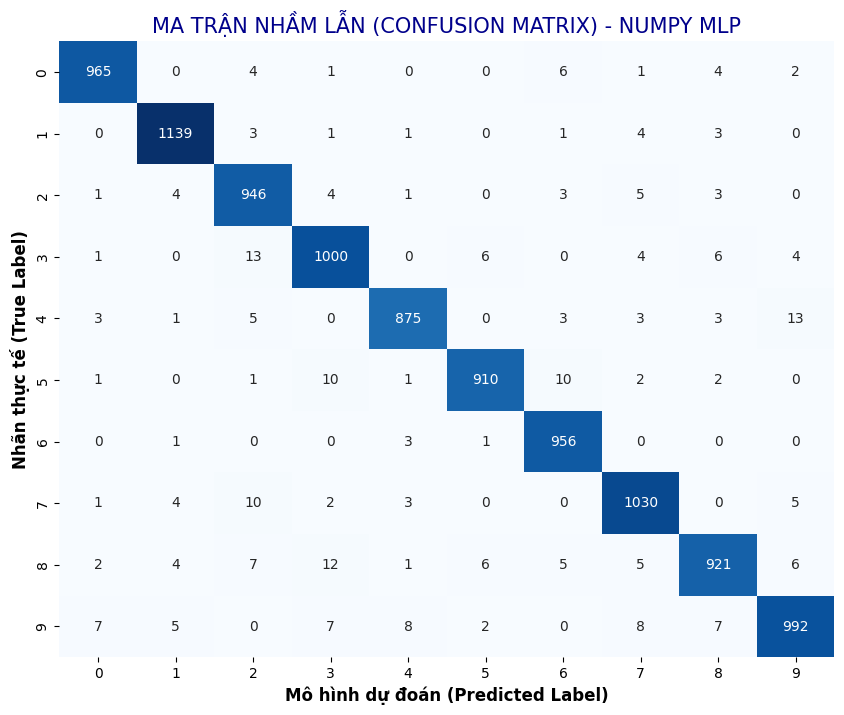

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Đang tiến hành đánh giá toàn diện trên tập Test (Thuần NumPy)")

# 1. Tải bộ não mô hình đã lưu từ ổ cứng
W1, b1, W2, b2 = load_model('numpy_mnist_model.npz')

# 2. Truyền toàn bộ 10.000 bức ảnh qua mạng nơ-ron CÙNG MỘT LÚC
# Không cần vòng lặp for, NumPy sẽ nhân ma trận siêu tốc cho toàn bộ dữ liệu
probabilities = forward_predict(X_test, W1, b1, W2, b2)

# Lấy nhãn có xác suất cao nhất cho từng bức ảnh (axis=1)
all_preds = np.argmax(probabilities, axis=1)
all_targets = y_test # Đáp án thực tế

# 3. In Báo cáo phân loại (Bao gồm Accuracy, Precision, Recall, F1-Score)
print("\nBÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT):")
print("-" * 55)
# Hàm classification_report sẽ tự động tính cả 4 chỉ số cho từng class (0-9)
print(classification_report(all_targets, all_preds, digits=4))

# 4. Trực quan hóa bằng Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(10, 8))
# Vẽ heatmap để hiện thị ma trận màu sắc
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Mô hình dự đoán (Predicted Label)', fontsize=12, fontweight='bold')
plt.ylabel('Nhãn thực tế (True Label)', fontsize=12, fontweight='bold')
plt.title('MA TRẬN NHẦM LẪN (CONFUSION MATRIX) - NUMPY MLP', fontsize=15, color='darkblue')
plt.show()